In [56]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/dataset.csv")
df_clean = df.copy()


In [57]:
# remplir les valeurzs manquant de 'CREDIT_LIMIT' :

df_clean["CREDIT_LIMIT"] = df_clean["CREDIT_LIMIT"].fillna(df_clean["CREDIT_LIMIT"].median())

In [58]:
# droping column 'CUST_ID' :

df_clean = df_clean.drop(columns=["CUST_ID"])
print(df_clean.columns.tolist())


['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']


In [59]:
df_prepare_clustering = df_clean.copy()

In [60]:
log_cols = [
               "BALANCE",
               "PURCHASES",
               "ONEOFF_PURCHASES",
               "INSTALLMENTS_PURCHASES",
               "CASH_ADVANCE",
               "CREDIT_LIMIT",
               "PAYMENTS"
           ]

In [61]:
skewness_before = df_prepare_clustering[log_cols].skew()

print((skewness_before))

BALANCE                    2.393386
PURCHASES                  8.144269
ONEOFF_PURCHASES          10.045083
INSTALLMENTS_PURCHASES     7.299120
CASH_ADVANCE               5.166609
CREDIT_LIMIT               1.522636
PAYMENTS                   5.907620
dtype: float64


In [62]:
for col in log_cols:
    df_prepare_clustering[col] = np.log1p(df_prepare_clustering[col])


skewness_after = df_prepare_clustering[log_cols].skew()

print(skewness_after)

BALANCE                  -0.861021
PURCHASES                -0.764492
ONEOFF_PURCHASES          0.185854
INSTALLMENTS_PURCHASES   -0.024981
CASH_ADVANCE              0.262594
CREDIT_LIMIT             -0.101408
PAYMENTS                 -1.778312
dtype: float64


In [63]:
skew_comparison = pd.DataFrame({
    "Skewness_Before": skewness_before,
    "Skewness_After": skewness_after
})

skew_comparison["Redection"] = (skew_comparison["Skewness_Before"] - skew_comparison["Skewness_After"])

skew_comparison

,Skewness_Before,Skewness_After,Redection
BALANCE,2.393386,-0.861021,3.254407
PURCHASES,8.144269,-0.764492,8.908761
ONEOFF_PURCHASES,10.045083,0.185854,9.859229
INSTALLMENTS_PURCHASES,7.299120,-0.024981,7.324101
CASH_ADVANCE,5.166609,0.262594,4.904015
CREDIT_LIMIT,1.522636,-0.101408,1.624044
PAYMENTS,5.907620,-1.778312,7.685931


- Histogrammes + KDE Aprés Log Transformation :

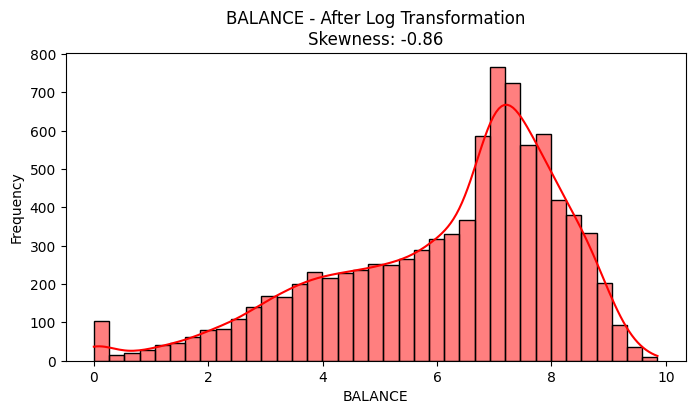

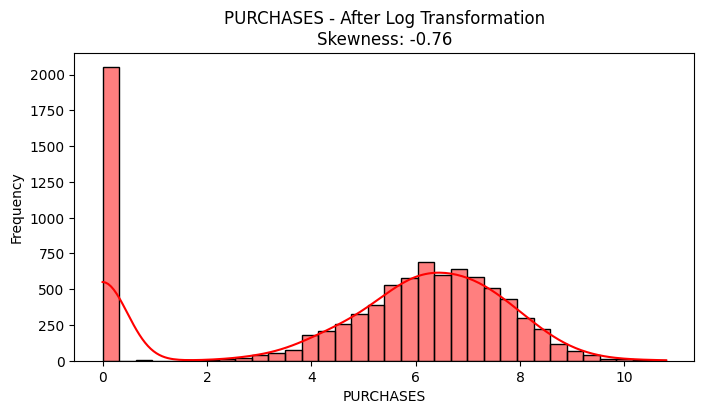

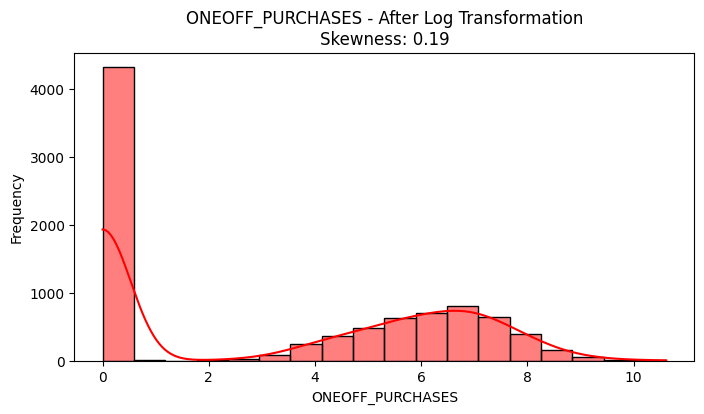

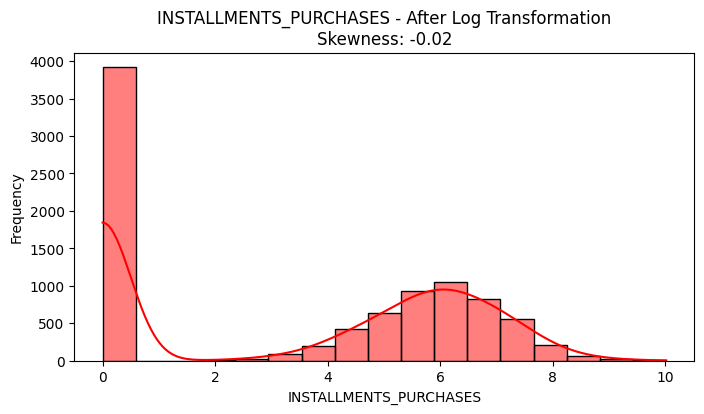

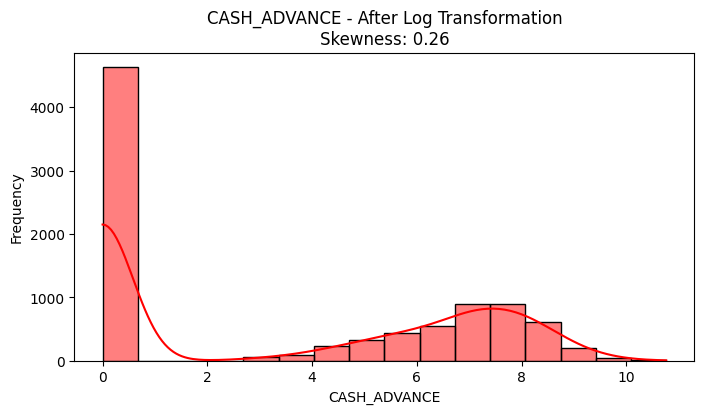

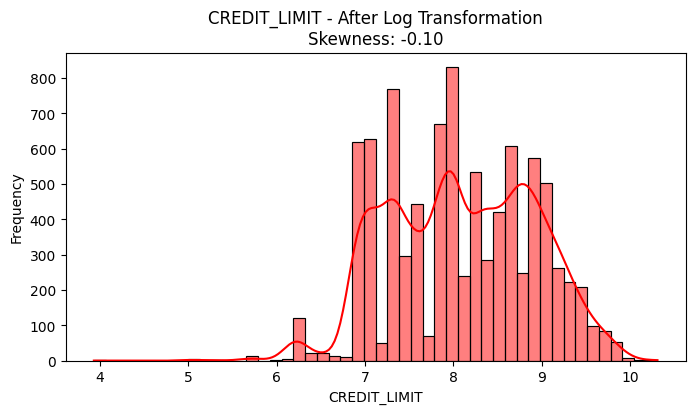

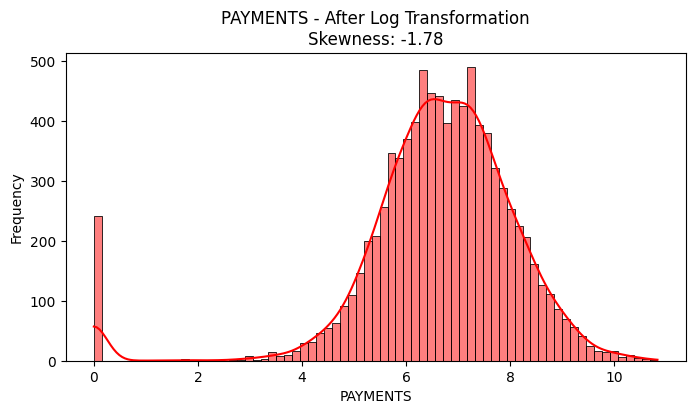

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in log_cols:

    plt.figure(figsize=(8, 4))

    sns.histplot(df_prepare_clustering[col], kde=True, color='red')

    plt.title(f"{col} - After Log Transformation\n"
        f"Skewness: {df_prepare_clustering[col].skew():.2f}"
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

- Standarisation :

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_prepare_clustering[log_cols])


# test
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=log_cols
)

print(X_scaled_df.mean())
print(X_scaled_df.std())

BALANCE                   1.270244e-17
PURCHASES                 6.986342e-17
ONEOFF_PURCHASES          2.540488e-17
INSTALLMENTS_PURCHASES    1.587805e-18
CASH_ADVANCE              5.716098e-17
CREDIT_LIMIT             -5.335025e-16
PAYMENTS                  3.556683e-16
dtype: float64
BALANCE                   1.000056
PURCHASES                 1.000056
ONEOFF_PURCHASES          1.000056
INSTALLMENTS_PURCHASES    1.000056
CASH_ADVANCE              1.000056
CREDIT_LIMIT              1.000056
PAYMENTS                  1.000056
dtype: float64


- PCA

In [67]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)



- Explained Variance

In [68]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.35366801 0.29256055 0.11395899 0.10007563 0.07623706 0.04969981
 0.01379994]


- Cumulative Explained Variance

In [69]:
cumulative_variance = explained_variance.cumsum()

print(cumulative_variance)

[0.35366801 0.64622856 0.76018756 0.86026318 0.93650025 0.98620006
 1.        ]


- Graph de PCA

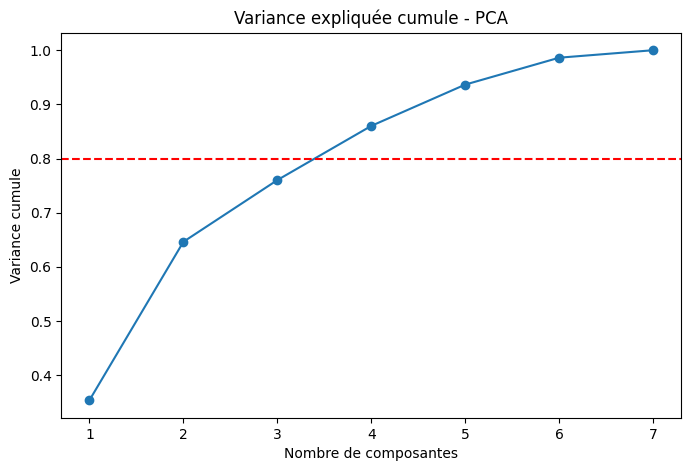

In [71]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(y=0.80,linestyle="--",color='red')

plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumule")
plt.title("Variance expliquée cumule - PCA")

plt.show()

In [73]:
n_components_initial = (cumulative_variance >= 0.80).argmax() + 1

print("Nombre minimal de composantes pour depasser 80% :",n_components_initial)

Nombre minimal de composantes pour depasser 80% : 4
